# Análise exploratória das features tratadas

Este notebook começa após a etapa de tratamento inicial da base SECOM. A intenção é comparar observações aprovadas e reprovadas, verificar quais variáveis mais diferenciam os grupos e preparar a base para a próxima etapa de estatística e SQL.

## Objetivos
- validar a base tratada;
- comparar grupos por qualidade;
- identificar variáveis candidatas;
- gerar os primeiros indicadores visuais.

In [2]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

raiz_projeto = Path.cwd().resolve()
if raiz_projeto.name == 'notebooks':
    raiz_projeto = raiz_projeto.parent

pasta_dados = raiz_projeto / 'data' / 'raw'
caminho_dados = pasta_dados / 'secom.data'
caminho_rotulos = pasta_dados / 'secom_labels.data'

dados = pd.read_csv(
    caminho_dados,
    sep=r'\s+',
    header=None,
    na_values='NaN',
    engine='python',
)

padrao_rotulo = re.compile(r'^\s*(-?\d+)\s+"([^"]+)"\s*$')
linhas_rotulos = caminho_rotulos.read_text(encoding='utf-8').splitlines()
rotulos_extraidos = [
    padrao_rotulo.match(linha).groups()
    for linha in linhas_rotulos
    if padrao_rotulo.match(linha)
]

rotulos = pd.DataFrame(rotulos_extraidos, columns=['rotulo', 'timestamp'])
rotulos['rotulo'] = rotulos['rotulo'].astype(int)
rotulos['timestamp'] = pd.to_datetime(
    rotulos['timestamp'],
    format='%d/%m/%Y %H:%M:%S',
)
rotulos['falha'] = (rotulos['rotulo'] == 1).astype(int)

# Tratamento inicial reproduzido para manter a base consistente
dados_tratados = dados.copy()
percentual_missing = dados_tratados.isna().mean()
colunas_constantes = dados_tratados.columns[
    dados_tratados.nunique(dropna=True) <= 1
]
colunas_excesso_missing = percentual_missing[
    percentual_missing > 0.50
].index
colunas_removidas = colunas_constantes.union(colunas_excesso_missing)

dados_tratados = dados_tratados.drop(columns=colunas_removidas)
medianas = dados_tratados.median(numeric_only=True)
dados_tratados = dados_tratados.fillna(medianas)

base_modelagem = dados_tratados.copy()
base_modelagem['falha'] = rotulos['falha'].to_numpy()

print(f"Base original: {dados.shape}")
print(f"Base tratada: {base_modelagem.shape}")
print(f"Rótulos: {rotulos.shape}")
print(f"Valores ausentes na base tratada: {base_modelagem.isna().sum().sum()}")
print(f"Taxa de falha: {base_modelagem['falha'].mean():.4f}")

Base original: (1567, 590)
Base tratada: (1567, 447)
Rótulos: (1567, 3)
Valores ausentes na base tratada: 0
Taxa de falha: 0.0664


In [3]:
# Validação inicial da base
assert len(dados) == len(rotulos), 'Número de linhas entre dados e rótulos diverge.'
assert base_modelagem.isna().sum().sum() == 0, 'Ainda existem valores ausentes na base tratada.'
assert set(base_modelagem['falha'].unique()) <= {0, 1}, 'Campo falha fora do domínio esperado.'

print('Validação concluída: base tratada consistente e pronta para exploração.')
base_modelagem.head()

Validação concluída: base tratada consistente e pronta para exploração.


,0,1,2,3,4,6,7,8,9,10,...,577,582,583,584,585,586,587,588,589,falha
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0


In [4]:
# Distribuição da variável resposta
distribuicao = base_modelagem['falha'].value_counts(normalize=True).sort_index()
distribuicao

falha
0    0.933631
1    0.066369
Name: proportion, dtype: float64

In [5]:
# Resumo comparativo por feature
features = [col for col in base_modelagem.columns if col != 'falha']
linhas = []

for coluna in features:
    aprovados = base_modelagem.loc[base_modelagem['falha'] == 0, coluna]
    falhas = base_modelagem.loc[base_modelagem['falha'] == 1, coluna]

    linhas.append({
        'feature': coluna,
        'media_aprovados': aprovados.mean(),
        'media_falhas': falhas.mean(),
        'diff_media': falhas.mean() - aprovados.mean(),
        'std_aprovados': aprovados.std(ddof=1),
        'std_falhas': falhas.std(ddof=1),
    })

resumo_features = pd.DataFrame(linhas).sort_values('diff_media', ascending=False)
resumo_features.head(15)

,feature,media_aprovados,media_falhas,diff_media,std_aprovados,std_falhas
142,159,862.112098,1167.028846,304.916748,939.746275,1432.593835
19,21,-5636.360219,-5363.822115,272.538103,593.603033,945.885433
143,160,541.533835,747.394231,205.860396,549.297580,833.403636
235,294,391.341226,546.780908,155.439682,453.536709,716.568505
236,295,246.024680,350.011196,103.986516,269.753684,421.515903
389,511,270.779172,343.826169,73.046998,327.426044,353.482752
21,23,-3811.042208,-3739.863782,71.178426,1375.173439,1441.072120
178,204,27.528829,96.334937,68.806107,522.232525,980.337467
62,67,13.417030,62.207330,48.790300,270.765071,623.921406
333,433,202.622281,245.226405,42.604124,223.214795,255.281367


In [6]:
# Ranking inicial das features mais divergentes
top_features = resumo_features.head(10).copy()
top_features[['feature', 'media_aprovados', 'media_falhas', 'diff_media']]

,feature,media_aprovados,media_falhas,diff_media
142,159,862.112098,1167.028846,304.916748
19,21,-5636.360219,-5363.822115,272.538103
143,160,541.533835,747.394231,205.860396
235,294,391.341226,546.780908,155.439682
236,295,246.024680,350.011196,103.986516
389,511,270.779172,343.826169,73.046998
21,23,-3811.042208,-3739.863782,71.178426
178,204,27.528829,96.334937,68.806107
62,67,13.417030,62.207330,48.790300
333,433,202.622281,245.226405,42.604124


C:\Users\kaire\AppData\Local\Temp\ipykernel_10144\2952169581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


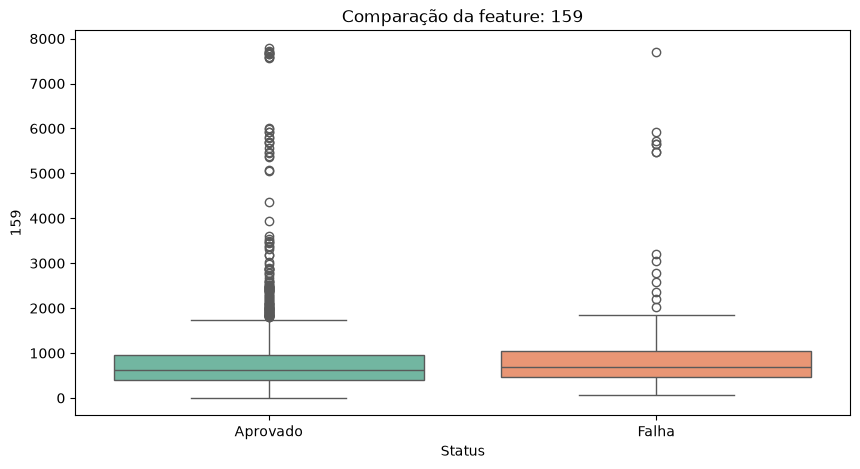

In [7]:
# Exemplo de visualização para uma feature candidata
feature_exemplo = top_features['feature'].iloc[0]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=base_modelagem,
    x='falha',
    y=feature_exemplo,
    palette='Set2'
)
plt.title(f'Comparação da feature: {feature_exemplo}')
plt.xlabel('Status')
plt.ylabel(feature_exemplo)
plt.xticks([0, 1], ['Aprovado', 'Falha'])
plt.show()

## Interpretação inicial

- As features com maior diferença média entre aprovados e reprovados são as primeiras candidatas a explicar variação de qualidade.
- Gráficos como boxplot ajudam a entender se a diferença é consistente ou se reflete apenas outliers.
- A análise exploratória deve ser usada para gerar hipóteses e priorizar variáveis para etapas posteriores, sem concluir causalidade.
- O próximo passo é ampliar a análise para várias features, validar a estabilidade dos sinais e preparar a base para estatística aplicada.

## Ranking final das features

A próxima célula ordena todas as variáveis pela diferença absoluta entre os grupos, permitindo identificar um ranking mais objetivo das features com maior potencial discriminante.

In [ ]:
# Ranking final das features por diferença entre grupos
features = [col for col in base_modelagem.columns if col != 'falha']

ranking = []

for col in features:
    aprovados = base_modelagem.loc[base_modelagem['falha'] == 0, col]
    falhas = base_modelagem.loc[base_modelagem['falha'] == 1, col]

    media_aprovados = aprovados.mean()
    media_falhas = falhas.mean()
    diff_media = media_falhas - media_aprovados

    ranking.append({
        'feature': col,
        'media_aprovados': media_aprovados,
        'media_falhas': media_falhas,
        'diff_media': diff_media,
        'abs_diff': abs(diff_media),
        'mediana_aprovados': aprovados.median(),
        'mediana_falhas': falhas.median(),
        'std_aprovados': aprovados.std(ddof=1),
        'std_falhas': falhas.std(ddof=1),
    })

ranking_df = pd.DataFrame(ranking).sort_values('abs_diff', ascending=False)
ranking_df.head(10)

In [ ]:
# Top 5 variáveis mais relevantes para investigação
Top5 = ranking_df.head(5).copy()
Top5[['feature', 'media_aprovados', 'media_falhas', 'diff_media', 'abs_diff']]

## Interpretação dos 5 mais relevantes

- As cinco variáveis com maior diferença entre aprovação e falha devem ser tratadas como candidatas prioritárias.
- Se a diferença aparece na média e também na mediana, isso indica um sinal mais robusto e menos sensível a outliers.
- Quando a dispersão do grupo com falha é maior, isso sugere maior instabilidade operacional ou comportamento mais heterogêneo.
- A interpretação deve focar em associação e potencial de monitoramento, não em causalidade.
- Essas variáveis podem virar indicadores de processo, alarmes ou variáveis de entrada para modelagem posterior.

## Roteiro para transformar isso em conclusão analítica

1. Selecionar as 5 features com maior diferença entre grupos.
2. Verificar se a direção da diferença faz sentido do ponto de vista do processo.
3. Confirmar se a diferença também aparece na mediana e não apenas na média.
4. Validar se os grupos apresentam separação visual consistente em boxplots.
5. Registrar hipóteses operacionais relevantes para monitoramento do processo.
6. Evitar afirmar causalidade; dizer apenas que há associação observada.
7. Usar esse resultado como base para estatística aplicada e indicadores no SQL.

# Gráficos mais fortes e seleção final das features

As três visualizações abaixo resumem os sinais mais relevantes observados entre os grupos. A seleção final de features deve priorizar variáveis com diferença consistente na média, na mediana e na distribuição, e não apenas um efeito isolado de outlier.

In [ ]:
# Gera o ranking final e identifica as 3 features mais relevantes
features = [col for col in base_modelagem.columns if col != 'falha']

ranking = []

for col in features:
    aprovados = base_modelagem.loc[base_modelagem['falha'] == 0, col]
    falhas = base_modelagem.loc[base_modelagem['falha'] == 1, col]

    media_aprovados = aprovados.mean()
    media_falhas = falhas.mean()
    diff_media = media_falhas - media_aprovados
    mediana_aprovados = aprovados.median()
    mediana_falhas = falhas.median()

    ranking.append({
        'feature': col,
        'media_aprovados': media_aprovados,
        'media_falhas': media_falhas,
        'diff_media': diff_media,
        'abs_diff': abs(diff_media),
        'mediana_aprovados': mediana_aprovados,
        'mediana_falhas': mediana_falhas,
        'std_aprovados': aprovados.std(ddof=1),
        'std_falhas': falhas.std(ddof=1),
    })

ranking_df = pd.DataFrame(ranking).sort_values('abs_diff', ascending=False)
selected_features = ranking_df.head(3)['feature'].tolist()
selected_features

In [ ]:
# 3 gráficos mais fortes para interpretação visual
a = 0
for feature in selected_features:
    a += 1
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=base_modelagem,
        x='falha',
        y=feature,
        palette='Set2'
    )
    plt.title(f'Gráfico {a}: {feature}')
    plt.xlabel('Status')
    plt.ylabel(feature)
    plt.xticks([0, 1], ['Aprovado', 'Falha'])
    plt.tight_layout()
    plt.show()

In [ ]:
# Tabela final das features selecionadas
ranking_df[ranking_df['feature'].isin(selected_features)][[
    'feature', 'media_aprovados', 'media_falhas', 'diff_media', 'abs_diff'
]]

# Ranking final e conclusão analítica

A análise exploratória indica que o conjunto de variáveis com maior separação entre grupos possui potencial de servir como sinal inicial de risco de falha. Ainda assim, os resultados devem ser interpretados como associação observada e não como relação causal.

A seleção final de features deve ser baseada em critérios de consistência: diferença de média, linha central da distribuição e comportamento visual em boxplot. Variáveis que só se destacam em um desses critérios devem ser tratadas como candidatas secundárias até que sua estabilidade seja confirmada.

Os indicadores mais promissores para a fase seguinte são aqueles que permanecem relevantes quando comparados por grupo, sem depender exclusivamente de valores extremos. Essa abordagem reduz o risco de sobreinterpretar ruído e aumenta a confiabilidade da base para estatística aplicada e para criação de indicadores em SQL.

Em termos analíticos, a exploração sugere que a qualidade do processo não é determinada por um único fator, mas por um conjunto de sinais distribuídos ao longo das medidas anonimizadas. A presença de diferenças consistentes entre os grupos indica que há informação útil para discriminar aprovação e falha, embora o significado físico de cada feature continue sendo anonimamente representado pela estrutura do dataset.

Desta forma, a etapa exploratória cumpriu seu papel de virar a base em um conjunto de hipóteses priorizadas. O próximo passo adequado é validar essas hipóteses com testes estatísticos, comparar efeitos operacionais e transformar as variáveis mais relevantes em indicadores de monitoramento e consulta no PostgreSQL.